# Low-rank RL 

This notebook is an interactive version of `experiments/run.py`. It trains an agent from following the `YAML` file in `\configs` and then runs the full low-rank analysis suite, rendering every plot inline.

See, `experiments/README.md` for the config schema and `low_rank_rl/analysis/README.md` for explaination behind the different metrics.  

## 1. Setup

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import pathlib
import sys

# walk up the tree until we find the package — that way the notebook works
# whether it's opened from the repo root or from inside experiments/
REPO_ROOT = pathlib.Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "low_rank_rl").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import yaml

from IPython.display import display, clear_output

from low_rank_rl.envs import make_env, rollout_policy, animate_rollout, plot_rollout_strip
from low_rank_rl.agents import (
    DQNAgent, QLearningAgent, SarsaAgent, MonteCarloAgent, PPOAgent,
)
from low_rank_rl.training import train
from low_rank_rl.analysis.rank import compute_rank_metrics, sample_states
from low_rank_rl.analysis.tensor import build_value_tensor, hosvd_spectra
from low_rank_rl.analysis.hankel import hankel_rank_metrics
from low_rank_rl.visualization.training import (
    plot_episode_durations,
    plot_episode_rewards,
)
from low_rank_rl.visualization.rank_analysis import (
    plot_singular_value_spectrum,
    plot_hosvd_spectra,
    plot_rank_vs_episode,
    plot_hankel_spectrum,
    plot_hankel_spectra_over_training,
)
from low_rank_rl.visualization.value_fn import plot_value_heatmap

print(f"Repo root: {REPO_ROOT}")

Repo root: /Users/souparna/Low-Rank-RL-TL


## 2. Config

Two ways to configure an experiment:

- **(A) Load a YAML** from `experiments/configs/` — same file that `run.py` consumes.
- **(B) Override** any field on the loaded config directly in Python.

You can skip (A) entirely and build the `cfg` dict from scratch.

In [2]:
CONFIG_PATH = REPO_ROOT / "experiments" / "configs" / "acrobot_dqn.yaml"

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

# Uncomment any of these if you just want a quick smoke test rather than a full run.
# cfg["training"]["n_episodes"] = 50
# cfg["training"]["rank_checkpoint_every"] = 10
# cfg["training"]["n_rank_samples"] = 256

# Capture Hankel spectra at every rank checkpoint. The training driver
# (`low_rank_rl.training._checkpoint`) rolls out one greedy-policy
# trajectory and records the Hankel singular-value spectrum for each
# named sequence on every checkpoint, attached to `log.rank_history`.
cfg.setdefault("analysis", {})["hankel_sequence_types"] = ["value", "q_taken"]

cfg

{'env_id': 'Acrobot-v1',
 'agent': 'dqn',
 'training': {'n_episodes': 300,
  'rank_checkpoint_every': 20,
  'n_rank_samples': 1024},
 'agent_kwargs': {'hidden': 128,
  'batch_size': 128,
  'gamma': 0.99,
  'lr': 0.0003,
  'tau': 0.005,
  'eps_start': 0.99,
  'eps_end': 0.01,
  'eps_decay': 12000,
  'buffer_capacity': 10000},
 'env_kwargs': {'normalize_obs': True,
  'discretize_obs': True,
  'n_state_bins': [7, 7, 7, 7, 11, 11]},
 'analysis': {'hankel_steps': None,
  'hankel_n_rows': None,
  'value_tensor_bins': None,
  'value_tensor_dims': [0, 1, 2, 3, 4, 5],
  'hankel_sequence_types': ['value', 'q_taken']},
 'output': {'save_dir': 'outputs/acrobot_dqn/version2', 'save_agent': True}}

## 3. Environment and agent

In [3]:
def build_agent(agent_name, env, kwargs):
    obs_space = env.observation_space
    n_obs     = obs_space.shape[0]
    n_actions = env.action_space.n
    if agent_name == "dqn":
        return DQNAgent(n_obs=n_obs, n_actions=n_actions, **kwargs)
    if agent_name in ("qlearning", "q_learning"):
        return QLearningAgent(n_actions=n_actions, obs_low=obs_space.low, obs_high=obs_space.high, **kwargs)
    if agent_name == "sarsa":
        return SarsaAgent(n_actions=n_actions, obs_low=obs_space.low, obs_high=obs_space.high, **kwargs)
    if agent_name == "monte_carlo":
        return MonteCarloAgent(n_actions=n_actions, obs_low=obs_space.low, obs_high=obs_space.high, **kwargs)
    if agent_name == "ppo":
        return PPOAgent(n_obs=n_obs, n_actions=n_actions, **kwargs)
    raise ValueError(f"Unknown agent: {agent_name!r}")


env   = make_env(cfg["env_id"], **cfg.get("env_kwargs", {}))
agent = build_agent(cfg["agent"], env, cfg.get("agent_kwargs", {}))
print(f"Env    : {cfg['env_id']}")
print(f"Agent  : {agent}")
print(f"Episodes: {cfg['training']['n_episodes']}")

Env    : Acrobot-v1
Agent  : DQNAgent(n_obs=6, n_actions=3, device=mps, eps=0.990)
Episodes: 300


### State-action coverage hook (set up before training)

The cell below wraps `agent.act` with a counter so that every `(state, action)` pair the agent ever produces — across training and the final greedy rollout — gets recorded into a per-obs-dim `(bin, action)` count tensor. We plot the result at the very end of the notebook.

In [4]:
# Cumulative state-action coverage instrumentation.
#
# Monkey-patch `agent.act` so every call records (state, action) into a
# per-dim count tensor. The counters accumulate from the very first training
# step through all subsequent calls on this agent instance, so they end up
# containing:
#   - every training transition (eps-greedy mix);
#   - every step of the live-Hankel greedy rollouts at each checkpoint;
#   - every step of the final greedy rollout in section 11.
# The Hankel-rollout contribution is small (~500 steps per checkpoint) vs the
# full training run, so we leave it in rather than thread a flag through the
# callback. The final rollout is what makes the very-end policy trajectory
# show up in the histogram.

from low_rank_rl.envs.wrappers import find_obs_discretizer

_disc = find_obs_discretizer(env)
if _disc is not None:
    _bin_edges    = _disc.bin_edges
    _bin_centers  = _disc.bin_centers
    _n_state_bins = list(_disc.n_bins)
else:
    _low  = env.observation_space.low
    _high = env.observation_space.high
    _n_state_bins = [21] * env.observation_space.shape[0]
    _bin_edges    = [np.linspace(_low[d], _high[d], _n_state_bins[d] + 1, dtype=np.float32)
                     for d in range(len(_n_state_bins))]
    _bin_centers  = [0.5 * (e[:-1] + e[1:]) for e in _bin_edges]

_n_actions = env.action_space.n
coverage   = [np.zeros((b, _n_actions), dtype=np.int64) for b in _n_state_bins]

_orig_act_unpatched = agent.act
def _counting_act(state, training: bool = True) -> int:
    a = _orig_act_unpatched(state, training=training)
    s = np.asarray(state, dtype=np.float32)
    for d in range(len(s)):
        idx = int(np.clip(np.digitize(s[d], _bin_edges[d][1:-1]),
                          0, _n_state_bins[d] - 1))
        coverage[d][idx, a] += 1
    return a
agent.act = _counting_act

print(f"Coverage counters initialised  ({_n_actions} actions, {len(_n_state_bins)} obs dims):")
for d, c in enumerate(coverage):
    print(f"  dim {d}: bins={c.shape[0]:3d}")

Coverage counters initialised  (3 actions, 6 obs dims):
  dim 0: bins=  7
  dim 1: bins=  7
  dim 2: bins=  7
  dim 3: bins=  7
  dim 4: bins= 11
  dim 5: bins= 11


## 4. Training

`low_rank_rl.training.train(agent, env, cfg, on_episode=...)` auto-selects the
correct loop for the agent (step-based for DQN/Q-learning/SARSA, episode-based
for Monte Carlo, PPO with bootstrapped `last_value` on truncation).

The cell below shows:

- a **tqdm progress bar** with rolling-mean reward in the postfix;
- a **live reward-vs-episode plot** that refreshes every `REFRESH_EVERY`
  episodes via an `on_episode` callback.

The DQN loop is from  [PyTorch RL tutorial](https://pytorch.org/tutorials/intermediate/reinforcement_q_learning.html);
the PPO loop is from [OpenAI Spinning Up's PPO](https://spinningup.openai.com/en/latest/algorithms/ppo.html).

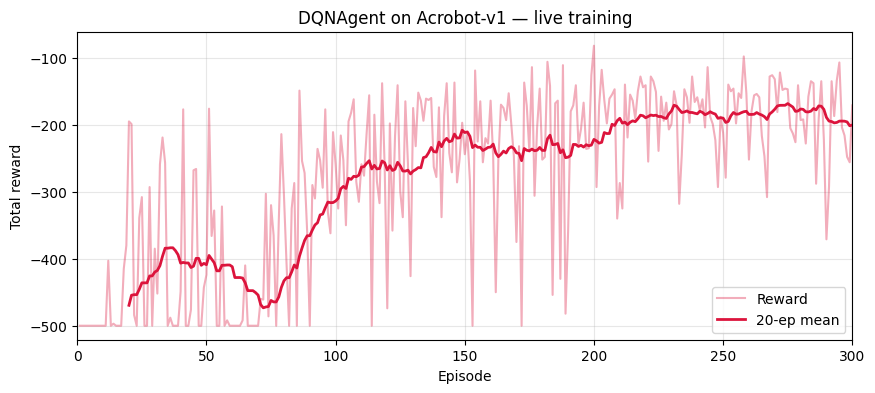

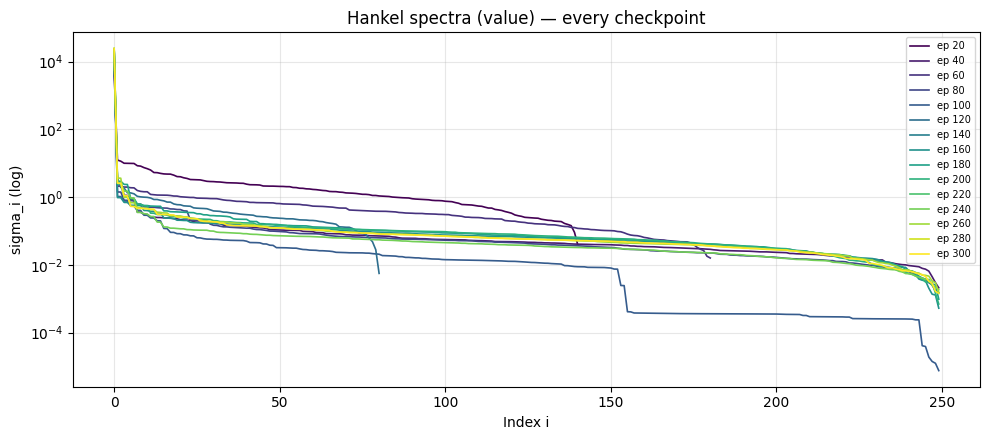

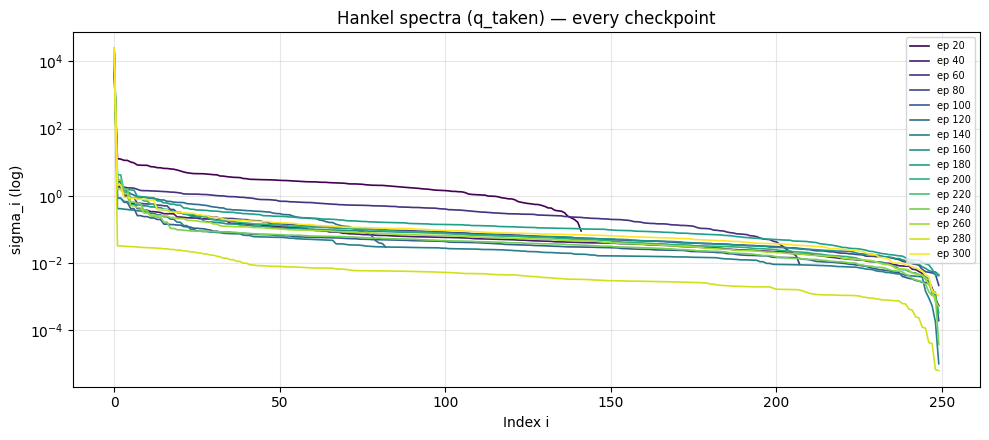

DQNAgent train:   0%|          | 0/300 [00:00<?, ?it/s]

  ep   20/300  dur= 196  R=-195.0  eps=0.458  Q-matrix 290521x3  |  numerical rank = 3/3
  ep   40/300  dur= 450  R=-449.0  eps=0.237  Q-matrix 290521x3  |  numerical rank = 3/3
  ep   60/300  dur= 500  R=-500.0  eps=0.124  Q-matrix 290521x3  |  numerical rank = 3/3
  ep   80/300  dur= 306  R=-305.0  eps=0.065  Q-matrix 290521x3  |  numerical rank = 3/3
  ep  100/300  dur= 260  R=-259.0  eps=0.043  Q-matrix 290521x3  |  numerical rank = 3/3
  ep  120/300  dur= 475  R=-474.0  eps=0.031  Q-matrix 290521x3  |  numerical rank = 3/3
  ep  140/300  dur= 175  R=-174.0  eps=0.024  Q-matrix 290521x3  |  numerical rank = 3/3
  ep  160/300  dur= 165  R=-164.0  eps=0.020  Q-matrix 290521x3  |  numerical rank = 3/3
  ep  180/300  dur= 253  R=-252.0  eps=0.017  Q-matrix 290521x3  |  numerical rank = 3/3
  ep  200/300  dur=  83  R=-82.0  eps=0.015  Q-matrix 290521x3  |  numerical rank = 3/3
  ep  220/300  dur= 142  R=-141.0  eps=0.013  Q-matrix 290521x3  |  numerical rank = 3/3
  ep  240/300  dur= 16

In [5]:
REFRESH_EVERY      = 5     # reward-plot refresh cadence (episodes)
HANKEL_SEQ_TYPES   = cfg.get("analysis", {}).get("hankel_sequence_types") or []
CHECKPOINT_EVERY   = cfg["training"]["rank_checkpoint_every"]

n_ep = cfg["training"]["n_episodes"]

# ---- live reward plot ------------------------------------------------------
fig_live, ax_live  = plt.subplots(figsize=(10, 4))
line_raw,          = ax_live.plot([], [], alpha=0.35, color="crimson", label="Reward")
line_avg,          = ax_live.plot([], [], color="crimson", linewidth=2, label="20-ep mean")
ax_live.set_xlim(0, n_ep)
ax_live.set_xlabel("Episode")
ax_live.set_ylabel("Total reward")
ax_live.set_title(f"{type(agent).__name__} on {cfg['env_id']} — live training")
ax_live.grid(True, alpha=0.3)
ax_live.legend(loc="lower right")
live_handle = display(fig_live, display_id="live_reward_plot")
plt.close(fig_live)

# ---- live Hankel spectrum plots (log scale, one figure per sequence type) --
# Just the spectrum overlay across checkpoints (colour = episode).
# Numerical-rank-vs-episode pane removed — the tol-based numerical rank is
# noisy and only meaningful in relation to the spectrum itself, so we plot
# every singular-value curve on a log y-axis and read decay/rank visually.
_hankel_history: list[dict] = []
_hankel_figs: dict[str, tuple] = {}
for _seq in HANKEL_SEQ_TYPES:
    _fig, _ax = plt.subplots(figsize=(10, 4.5))
    _ax.set_xlabel("Index i")
    _ax.set_ylabel("sigma_i (log)")
    _ax.set_yscale("log")
    _ax.set_title(f"Hankel spectra ({_seq}) — every checkpoint")
    _ax.grid(True, which="both", alpha=0.3)
    _handle = display(_fig, display_id=f"live_hankel_{_seq}")
    plt.close(_fig)
    _hankel_figs[_seq] = (_fig, _ax, _handle)

_reward_buffer: list[float] = []

def _refresh_hankel_figure(seq: str) -> None:
    fig, ax, handle = _hankel_figs[seq]
    entries = [h for h in _hankel_history if seq in h.get("hankel", {})]
    if not entries:
        return

    ax.cla()
    cmap = plt.cm.viridis
    n    = len(entries)
    for i, h in enumerate(entries):
        hm    = h["hankel"][seq]
        color = cmap(i / max(1, n - 1))
        ax.plot(hm.singular_values, "-", color=color, linewidth=1.2,
                label=f"ep {h['episode']}")
    ax.set_yscale("log")
    ax.set_xlabel("Index i")
    ax.set_ylabel("sigma_i (log)")
    ax.set_title(f"Hankel spectra ({seq}) — every checkpoint")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=7, ncol=max(1, n // 10), loc="upper right")

    fig.tight_layout()
    handle.update(fig)

def _on_episode(ep: int, duration: int, reward: float) -> None:
    _reward_buffer.append(reward)

    # Reward plot — refresh every REFRESH_EVERY episodes and on the final ep.
    if ep % REFRESH_EVERY == 0 or ep == n_ep:
        xs = np.arange(1, len(_reward_buffer) + 1)
        ys = np.asarray(_reward_buffer, dtype=float)
        line_raw.set_data(xs, ys)
        w = min(20, len(ys))
        if w > 1:
            avg = np.convolve(ys, np.ones(w) / w, mode="valid")
            line_avg.set_data(np.arange(w, len(ys) + 1), avg)
        ax_live.relim()
        ax_live.autoscale_view(scalex=False, scaley=True)
        live_handle.update(fig_live)

    # Hankel checkpoint — fires on the same episodes as `_checkpoint` inside
    # train_step_based. `hankel_rank_metrics(..., use_greedy=True)` rolls out
    # via `agent.act(obs, training=False)`, which is argmax-only (no eps),
    # so the rollout is independent of the eps-greedy training schedule.
    if HANKEL_SEQ_TYPES and ep % CHECKPOINT_EVERY == 0:
        analysis_cfg = cfg.get("analysis", {}) or {}
        entry = {"episode": ep, "hankel": {}}
        for seq in HANKEL_SEQ_TYPES:
            entry["hankel"][seq] = hankel_rank_metrics(
                agent, env,
                sequence_type=seq,
                n_steps=analysis_cfg.get("hankel_steps"),
                n_rows=analysis_cfg.get("hankel_n_rows"),
            )
        _hankel_history.append(entry)
        for seq in HANKEL_SEQ_TYPES:
            _refresh_hankel_figure(seq)

log = train(agent, env, cfg, on_episode=_on_episode, progress=True)
durations, rewards, rank_history = log.durations, log.rewards, log.rank_history

print(f"\nTrained {len(durations)} episodes — last reward = {rewards[-1]:+.1f}, "
      f"best = {max(rewards):+.1f}, mean(last 20) = {np.mean(rewards[-20:]):+.1f}")

## 5. Training plots

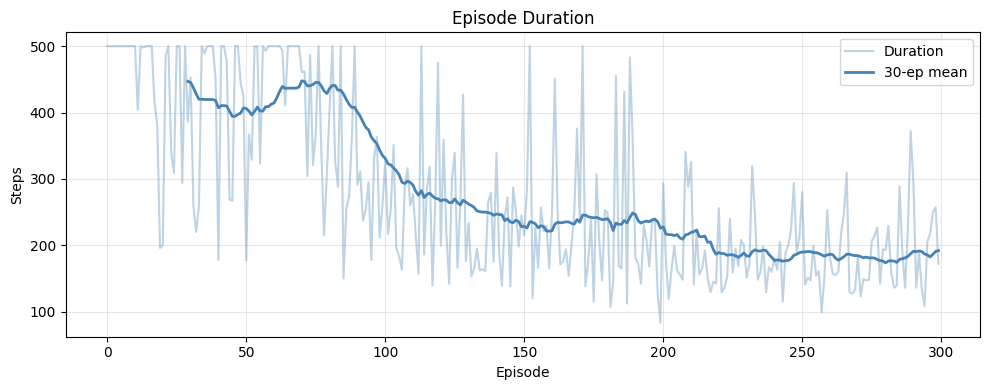

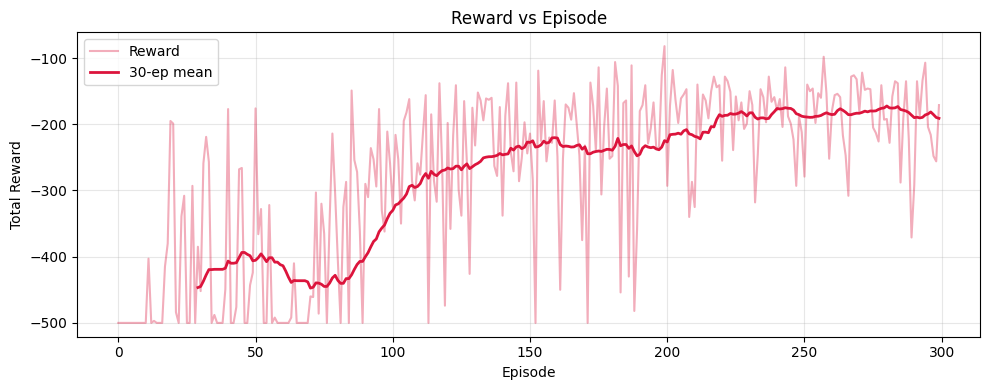

In [6]:
plot_episode_durations(durations, window=max(5, len(durations) // 10))
plt.show()

plot_episode_rewards(rewards, window=max(5, len(rewards) // 10))
plt.show()

## 6. Q-matrix rank analysis

$Q \in \mathbb{R}^{N \times |\mathcal A|}$. When the env is discretised, `sample_states` returns the **full canonical grid** (one row per bin centre), so this is the exact tabular rank. Otherwise $N$ states are drawn under a uniform random policy.

See `low_rank_rl/analysis/README.md` for the numerical / stable / effective rank definitions.

Probe states: 290521
Q-matrix 290521x3  |  numerical rank = 3/3


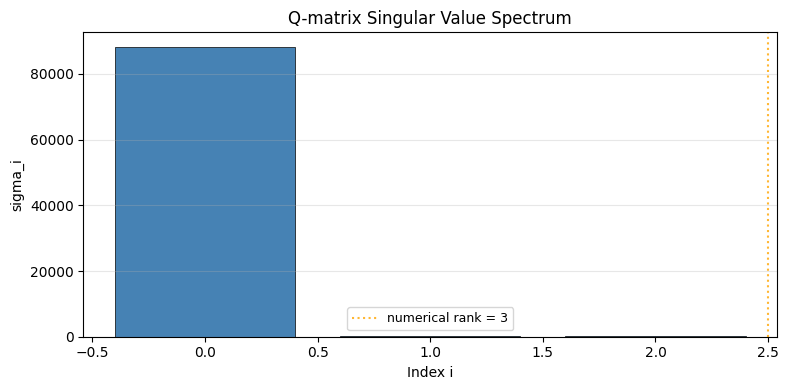

In [7]:
probe_states = sample_states(env, cfg["training"]["n_rank_samples"])
print(f"Probe states: {probe_states.shape[0]}")
metrics = compute_rank_metrics(agent, probe_states)
print(metrics.summary())
plot_singular_value_spectrum(metrics)
plt.show()

## 7. Value tensor (HOSVD)

Builds $\mathcal V_{i_1 \dots i_k} \approx \mathrm{mean}\{V(s) : s \in \text{bin}(i_1, \dots, i_k)\}$ and plots the singular values of each mode-$n$ unfolding.

Value tensor shape: (7, 7, 7, 7, 11, 11)


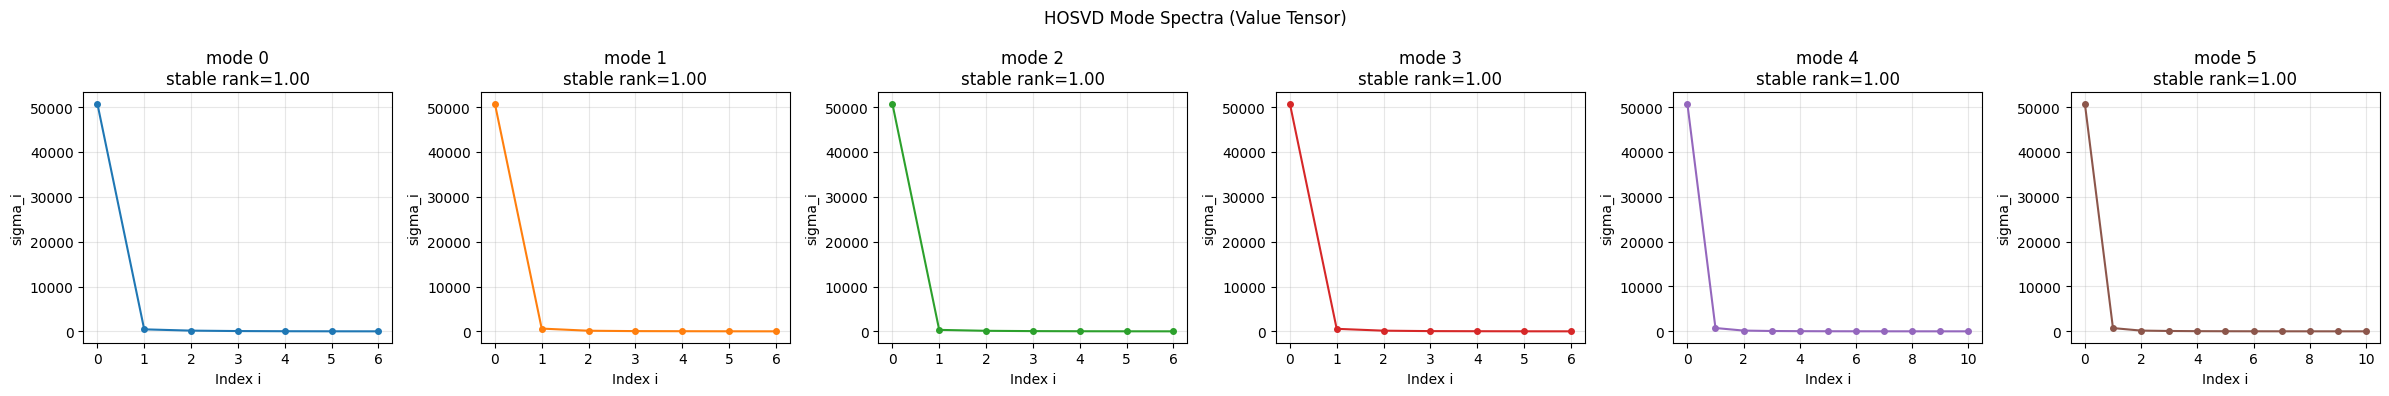

In [8]:
analysis_cfg = cfg.get("analysis", {})
V_tensor = build_value_tensor(
    agent, env,
    dims=analysis_cfg.get("value_tensor_dims"),
    n_bins=analysis_cfg.get("value_tensor_bins"),  # leave as None and we'll reuse the wrapper's grid if it has one
    n_samples=min(20_000, cfg["training"]["n_rank_samples"] * 50),
)
print(f"Value tensor shape: {V_tensor.shape}")

spectra = hosvd_spectra(V_tensor)
plot_hosvd_spectra(spectra)
plt.show()

## 8. Hankel analysis

Rolls out one full trajectory under the current greedy policy $\pi$ (i.e. the agent's current best estimate of the optimal policy), then builds the Hankel matrix $H_{ij} = f_{i+j}$ for a scalar sequence $f_t$ extracted from the trajectory. We look at several channels:

- `value`:   $f_t = V(s_t) = \max_a Q(s_t, a)$
- `q_taken`: $f_t = Q(s_t, a_t)$
- `policy`:  $f_t = \arg\max_a Q(s_t, a)$
- `actions`: $f_t = a_t$

`n_steps=None` runs to natural termination or `env.spec.max_episode_steps`, and `n_rows=None` picks a square Hankel (`T//2`) — the choice that maximises `min(n_rows, n_cols)` and thus the largest rank we can detect. Low Hankel rank $\leftrightarrow$ approximate finite-dimensional (Koopman-like) linear dynamics of that scalar along the trajectory.

Hankel(value) 250x251  |  seq_len=500  |  num_rank=13/250


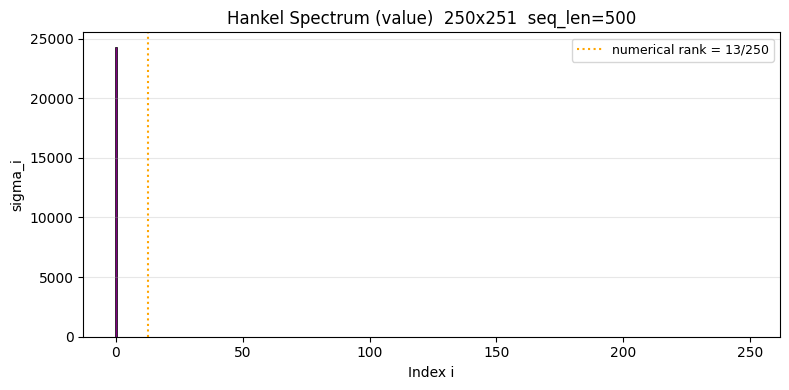

Hankel(q_taken) 250x251  |  seq_len=500  |  num_rank=24/250


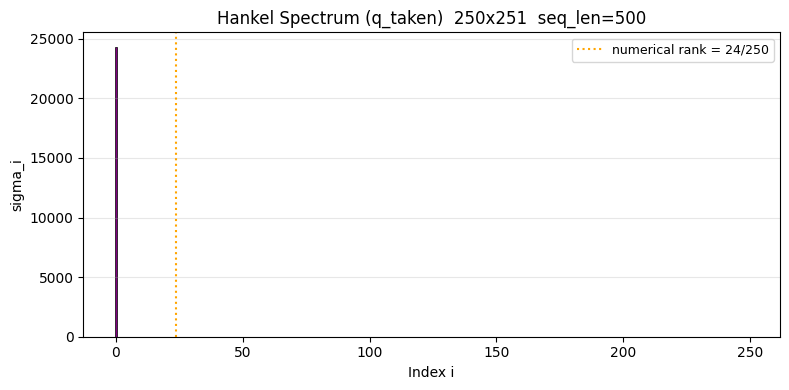

In [9]:
for seq_type in ("value", "q_taken"):
    hm = hankel_rank_metrics(
        agent, env,
        sequence_type=seq_type,
        n_steps=analysis_cfg.get("hankel_steps"),   # None just means "let the episode run to its natural end"
        n_rows=analysis_cfg.get("hankel_n_rows"),   # None gives a square Hankel (T // 2) — usually what you want
    )
    print(hm.summary())
    plot_hankel_spectrum(hm)
    plt.show()

## 10. Value heatmap

2-D slice of $V(s) = \max_a Q(s, a)$. For >2-D observations, all dimensions except the two on the axes are pinned at their mid-range. Tweak `dims` / `fixed_values` to explore other slices.

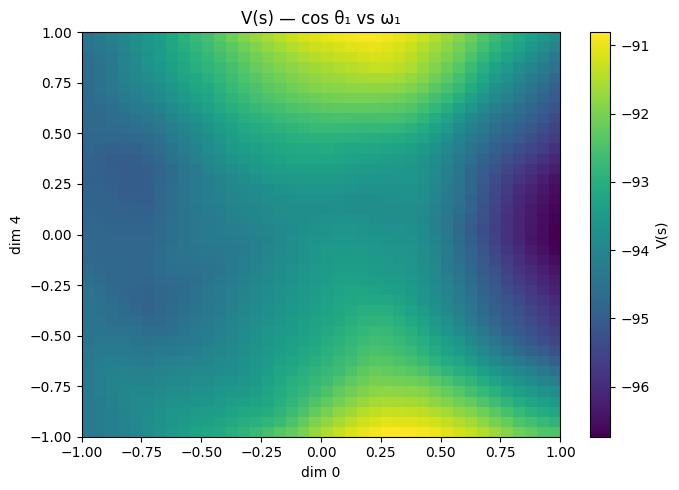

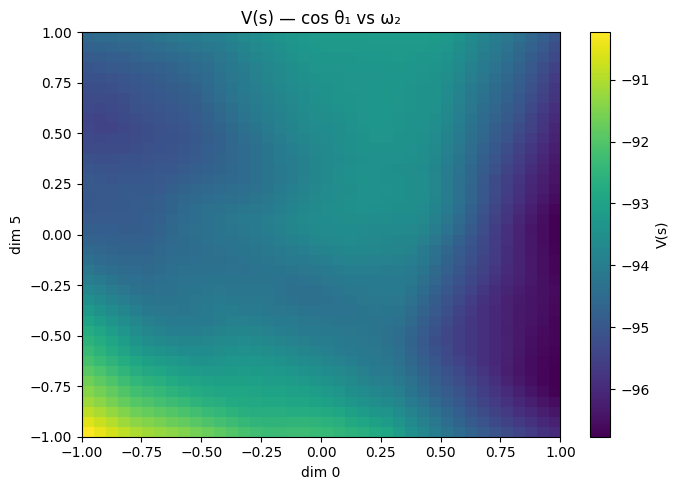

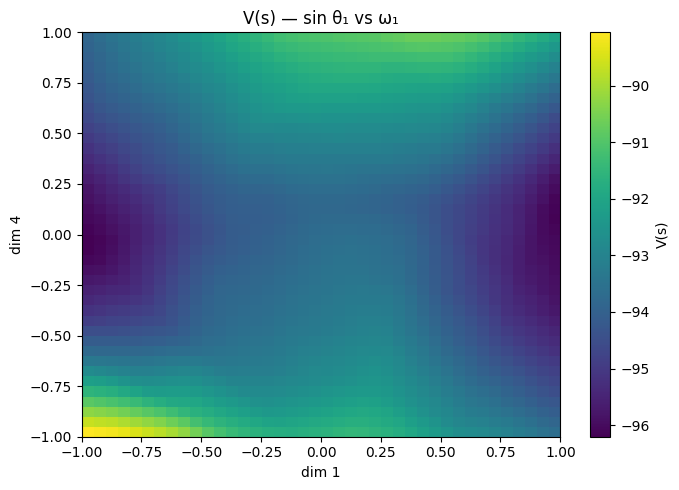

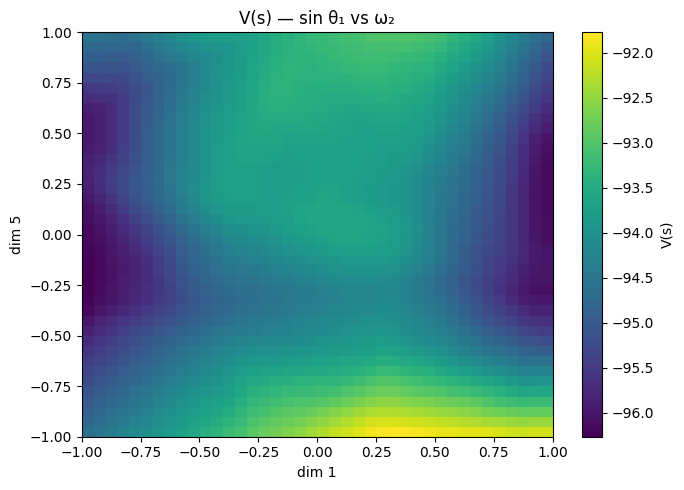

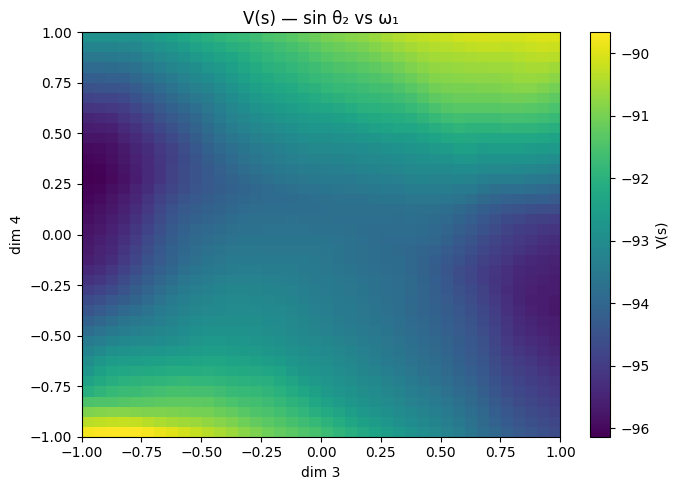

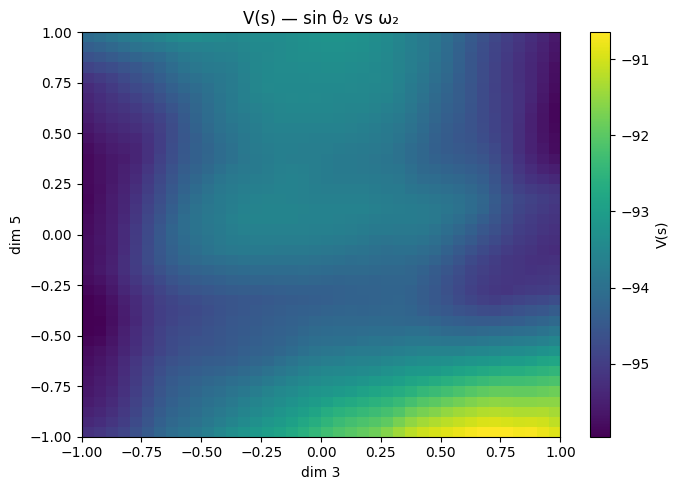

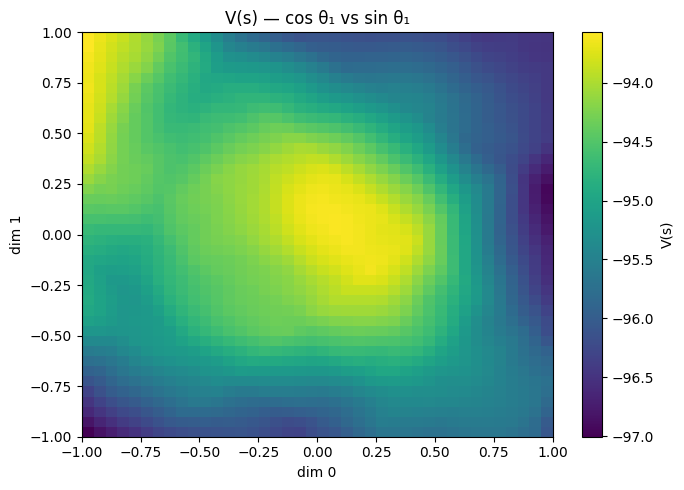

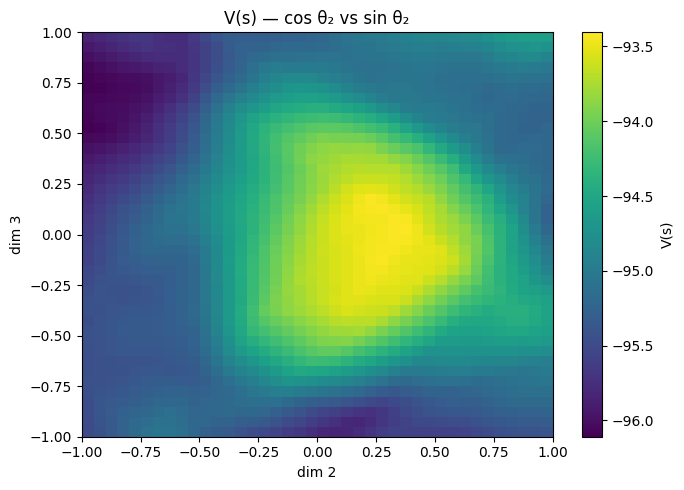

In [10]:
# Acrobot obs dims: 0=cos θ₁, 1=sin θ₁, 2=cos θ₂, 3=sin θ₂, 4=ω₁, 5=ω₂.
# Other dims not on the axes are pinned to their mid-range by plot_value_heatmap.
_DIM_LABELS = {0: "cos θ₁", 1: "sin θ₁", 2: "cos θ₂", 3: "sin θ₂", 4: "ω₁", 5: "ω₂"}

heatmap_slices = [
    (0, 4),   # cos θ₁ vs ω₁
    (0, 5),   # cos θ₁ vs ω₂
    (1, 4),   # sin θ₁ vs ω₁
    (1, 5),   # sin θ₁ vs ω₂
    (3, 4),   # sin θ₂ vs ω₁
    (3, 5),   # sin θ₂ vs ω₂
    (0, 1),   # cos θ₁ vs sin θ₁  (unit-circle slice for link 1)
    (2, 3),   # cos θ₂ vs sin θ₂  (unit-circle slice for link 2)
]

for dx, dy in heatmap_slices:
    plot_value_heatmap(
        agent, env,
        dims=(dx, dy),
        n_bins=40,
        title=f"V(s) — {_DIM_LABELS[dx]} vs {_DIM_LABELS[dy]}",
    )
    plt.show()

## 11. View the learnt policy

Roll out the trained agent **greedily** on a fresh env (built with `render_mode="rgb_array"` so we get back NumPy frames), then either play it inline as an animation or look at a static strip of evenly-sampled frames.

The agent's `act(..., training=False)` path is used, so the policy is deterministic (argmax of $Q$ for value-based agents, argmax of action probs for PPO).


In [19]:
rollout = rollout_policy(
    agent,
    cfg["env_id"],
    env_kwargs=cfg.get("env_kwargs"),
    max_steps=500,
    seed=40,
)
print(f"steps={rollout.n_steps}  total_reward={rollout.total_reward:+.2f}  "
      f"terminated={rollout.terminated}  truncated={rollout.truncated}")
print(f"frames captured: {len(rollout.frames)}")


steps=500  total_reward=-500.00  terminated=False  truncated=True
frames captured: 501


Inline animation (uses `matplotlib.animation` -> JS HTML — works in Jupyter / VSCode notebooks):


In [ ]:
from IPython.display import HTML

ani = animate_rollout(
    rollout.frames,
    interval=40,
    title=f"{type(agent).__name__} on {cfg['env_id']} (R={rollout.total_reward:+.2f})",
)
HTML(ani.to_jshtml())


: 

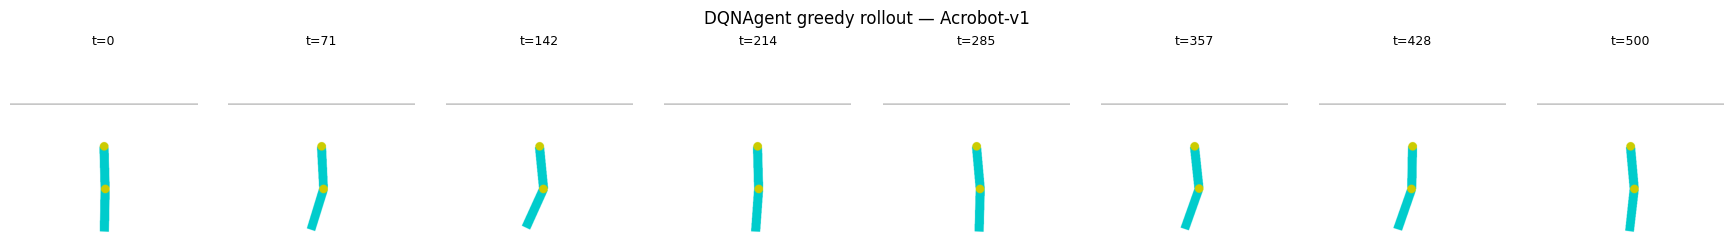

In [13]:
plot_rollout_strip(rollout.frames, n_cols=8,
                   title=f"{type(agent).__name__} greedy rollout — {cfg['env_id']}")
plt.show()


Optionally save the rollout as a GIF:


In [14]:
SAVE_GIF = True
if SAVE_GIF:
    from low_rank_rl.envs import save_rollout_gif
    out_dir = REPO_ROOT / cfg["output"]["save_dir"]
    out_dir.mkdir(parents=True, exist_ok=True)
    gif_path = out_dir / "policy_rollout.gif"
    save_rollout_gif(rollout.frames, str(gif_path), fps=25)
    print(f"Saved {gif_path}")


Saved /Users/souparna/Low-Rank-RL-TL/outputs/acrobot_dqn/version2/policy_rollout.gif


## State-action coverage (cumulative over the whole run)

Six stacked-bar histograms — one per obs dim — showing how many times each `(bin, action)` pair was visited from the very first training step through the final greedy rollout. Action 0/1/2 are stacked per bin, so the total bar height is the marginal visit count for that bin and the colour split shows the action mix the agent used while there. Use this to spot regions of state space the agent never reached or only ever took one action in.

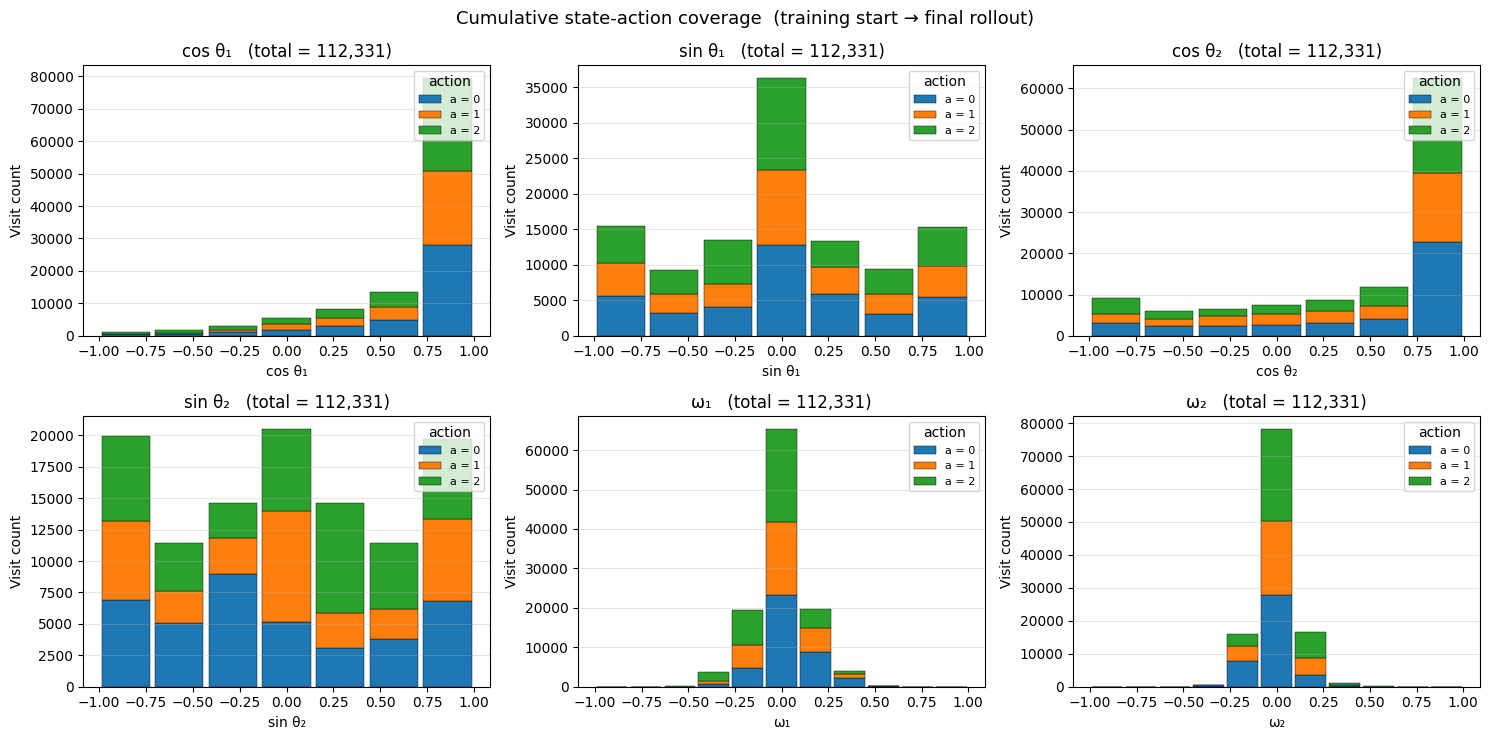

In [15]:
# Six stacked-bar histograms of cumulative state-action coverage. The
# counters were populated by the monkey-patched `agent.act` from the
# very first training step through the final greedy rollout above.
_DIM_LABELS_COV = {0: "cos θ₁", 1: "sin θ₁", 2: "cos θ₂",
                   3: "sin θ₂", 4: "ω₁",     5: "ω₂"}
_ACTION_COLORS  = ["#1f77b4", "#ff7f0e", "#2ca02c"]

n_dims = len(coverage)
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for d in range(n_dims):
    ax      = axes.flat[d]
    counts  = coverage[d]                                     # (n_bins, n_actions)
    centers = _bin_centers[d]
    width   = (centers[1] - centers[0]) * 0.9 if len(centers) > 1 else 0.1
    bottom  = np.zeros(counts.shape[0], dtype=np.float64)
    for a in range(_n_actions):
        ax.bar(centers, counts[:, a], width=width, bottom=bottom,
               color=_ACTION_COLORS[a % len(_ACTION_COLORS)],
               edgecolor="black", linewidth=0.3, label=f"a = {a}")
        bottom += counts[:, a]
    label = _DIM_LABELS_COV.get(d, f"dim {d}")
    ax.set_xlabel(label)
    ax.set_ylabel("Visit count")
    ax.set_title(f"{label}   (total = {counts.sum():,})")
    ax.grid(True, alpha=0.3, axis="y")
    ax.legend(fontsize=8, title="action", loc="upper right")

fig.suptitle("Cumulative state-action coverage  (training start → final rollout)",
             fontsize=13)
fig.tight_layout()
plt.show()

## 12. (Optional) save agent and close env

In [16]:
SAVE = True  # turn this off if you're just poking around and don't want files on disk
if SAVE:
    out_dir = REPO_ROOT / cfg["output"]["save_dir"]
    out_dir.mkdir(parents=True, exist_ok=True)
    agent.save(out_dir / "agent.pt")
    print(f"Saved to {out_dir}/agent.pt")

env.close()

Saved to /Users/souparna/Low-Rank-RL-TL/outputs/acrobot_dqn/version2/agent.pt
